In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np

In [5]:
# --- Component 1: On-the-fly Mask Generator ---
# LaMa works best when trained with aggressive masking (wide holes).
class RandomMaskGenerator:
    def __init__(self, height, width, min_bbox_shape=30, max_bbox_shape=60):
        self.height = height
        self.width = width
        self.min_bbox = min_bbox_shape
        self.max_bbox = max_bbox_shape

    def __call__(self):
        # Initialize a mask of zeros (0 = valid pixel, 1 = missing hole)
        mask = np.zeros((self.height, self.width), dtype=np.float32)
        
        # Determine random box size
        h = np.random.randint(self.min_bbox, self.max_bbox)
        w = np.random.randint(self.min_bbox, self.max_bbox)
        
        # Determine random top-left corner
        y = np.random.randint(0, self.height - h)
        x = np.random.randint(0, self.width - w)
        
        # Draw the box (set to 1)
        mask[y:y+h, x:x+w] = 1.0
        
        # Convert to torch tensor [1, H, W]
        return torch.from_numpy(mask).unsqueeze(0)

# --- Component 2: Dataset Wrapper ---
class InpaintingDataset(Dataset):
    def __init__(self, root='../kaggle/working/', train=True, img_size=128):
        # We use CIFAR10 for easy downloading, but Resize to 128x128
        # to simulate a resolution where FFC is actually useful.
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(), # [0, 1]
        ])
        
        self.base_dataset = torchvision.datasets.CIFAR10(
            root=root, train=train, download=True, transform=self.transform
        )
        self.mask_gen = RandomMaskGenerator(img_size, img_size)

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        ground_truth, _ = self.base_dataset[idx] # [3, H, W]
        mask = self.mask_gen()                   # [1, H, W]
        
        # Create the masked input image
        # We replace the hole with 0 (black) or noise. 
        # LaMa concatenates the mask, so the network knows where the hole is.
        masked_image = ground_truth * (1 - mask)
        
        return {
            "ground_truth": ground_truth,
            "masked_image": masked_image,
            "mask": mask
        }

In [6]:
# --- Component 3: The FFC Architecture ---

class SpectralTransform(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels * 2, out_channels * 2, 1, bias=False),
            nn.BatchNorm2d(out_channels * 2),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # FFT -> Mix -> IFFT
        ffted = torch.fft.rfft2(x, norm="ortho")
        f_input = torch.cat([ffted.real, ffted.imag], dim=1)
        f_output = self.conv(f_input)
        real, imag = torch.chunk(f_output, 2, dim=1)
        return torch.fft.irfft2(torch.complex(real, imag), s=x.shape[2:], norm="ortho")

class FFCResNetBlock(nn.Module):
    def __init__(self, dim, ratio=0.5):
        super().__init__()
        cg = int(dim * ratio)
        cl = dim - cg
        
        # Local Branch
        self.convl = nn.Sequential(
            nn.Conv2d(cl, cl, 3, padding=1, bias=False),
            nn.BatchNorm2d(cl),
            nn.ReLU(True),
            nn.Conv2d(cl, cl, 3, padding=1, bias=False),
            nn.BatchNorm2d(cl)
        )
        
        # Global Branch (FFT)
        self.convg = nn.Sequential(
            SpectralTransform(cg, cg),
            SpectralTransform(cg, cg) # Simplified stack
        )

    def forward(self, x):
        # Split -> Process -> Fuse
        cg = x.shape[1] // 2
        cl = x.shape[1] - cg
        xl, xg = torch.split(x, [cl, cg], dim=1)
        
        return F.relu(x + torch.cat([self.convl(xl), self.convg(xg)], dim=1))

class LaMaGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc = nn.Sequential(
            nn.ReflectionPad2d(3), nn.Conv2d(4, 64, 7), nn.ReLU(True), # Input 4 channels (RGB+Mask)
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU(True),
            nn.Conv2d(128, 256, 3, stride=2, padding=1), nn.ReLU(True)
        )
        
        # Bottleneck (FFC)
        self.bottleneck = nn.Sequential(
            FFCResNetBlock(256),
            FFCResNetBlock(256),
            FFCResNetBlock(256) 
        )
        
        # Decoder
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1), nn.ReLU(True),
            nn.ReflectionPad2d(3), nn.Conv2d(64, 3, 7), nn.Sigmoid() # Output RGB [0, 1]
        )

    def forward(self, img, mask):
        x = torch.cat([img, mask], dim=1) # Concatenate along channel dim
        x = self.enc(x)
        x = self.bottleneck(x)
        x = self.dec(x)
        return x

In [10]:
# --- Component 4: Training Loop ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LaMaGenerator().to(device)

def train_one_epoch():
    # 1. Setup Device & Hyperparams
    BATCH_SIZE = 8 # Small batch for demo
    LR = 1e-3
    
    print(f"Training on: {device}")

    # 2. Prepare Data
    # NOTE: Downloads CIFAR10 (~160MB) if not present
    dataset = InpaintingDataset(img_size=128)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    # 3. Initialize Model
    optimizer = optim.Adam(model.parameters(), lr=LR)
    
    # Loss Function
    # In production, LaMa uses Perceptual Loss (VGG) + Adversarial Loss (Discriminator).
    # For this script, we use L1 Loss (reconstruction) for simplicity.
    criterion = nn.L1Loss()

    model.train()
    
    # 4. Loop
    for batch_idx, data in enumerate(dataloader):
        ground_truth = data["ground_truth"].to(device)
        masked_image = data["masked_image"].to(device)
        mask = data["mask"].to(device)

        # Forward Pass
        # The model tries to predict the COMPLETED image
        predicted_image = model(masked_image, mask)

        # Calculate Loss
        # We only care about the loss INSIDE the hole (masked region),
        # though typically we calculate loss over the whole image.
        # Standard LaMa Loss = High Receptive Field Perceptual Loss
        loss = criterion(predicted_image, ground_truth)

        # Backward Pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch_idx % 10 == 0:
            print(f"Batch {batch_idx}/{len(dataloader)} | Reconstruction Loss: {loss.item():.4f}")


if __name__ == "__main__":
    train_one_epoch()

Training on: cuda
Batch 0/6250 | Reconstruction Loss: 0.1693
Batch 10/6250 | Reconstruction Loss: 0.1266
Batch 20/6250 | Reconstruction Loss: 0.0876
Batch 30/6250 | Reconstruction Loss: 0.0858
Batch 40/6250 | Reconstruction Loss: 0.0968
Batch 50/6250 | Reconstruction Loss: 0.0917
Batch 60/6250 | Reconstruction Loss: 0.0754
Batch 70/6250 | Reconstruction Loss: 0.0761
Batch 80/6250 | Reconstruction Loss: 0.0776
Batch 90/6250 | Reconstruction Loss: 0.0768
Batch 100/6250 | Reconstruction Loss: 0.0887
Batch 110/6250 | Reconstruction Loss: 0.0661
Batch 120/6250 | Reconstruction Loss: 0.0895
Batch 130/6250 | Reconstruction Loss: 0.0754
Batch 140/6250 | Reconstruction Loss: 0.0726
Batch 150/6250 | Reconstruction Loss: 0.0960
Batch 160/6250 | Reconstruction Loss: 0.0981
Batch 170/6250 | Reconstruction Loss: 0.1107
Batch 180/6250 | Reconstruction Loss: 0.0747
Batch 190/6250 | Reconstruction Loss: 0.1063
Batch 200/6250 | Reconstruction Loss: 0.0825
Batch 210/6250 | Reconstruction Loss: 0.0579
Bat

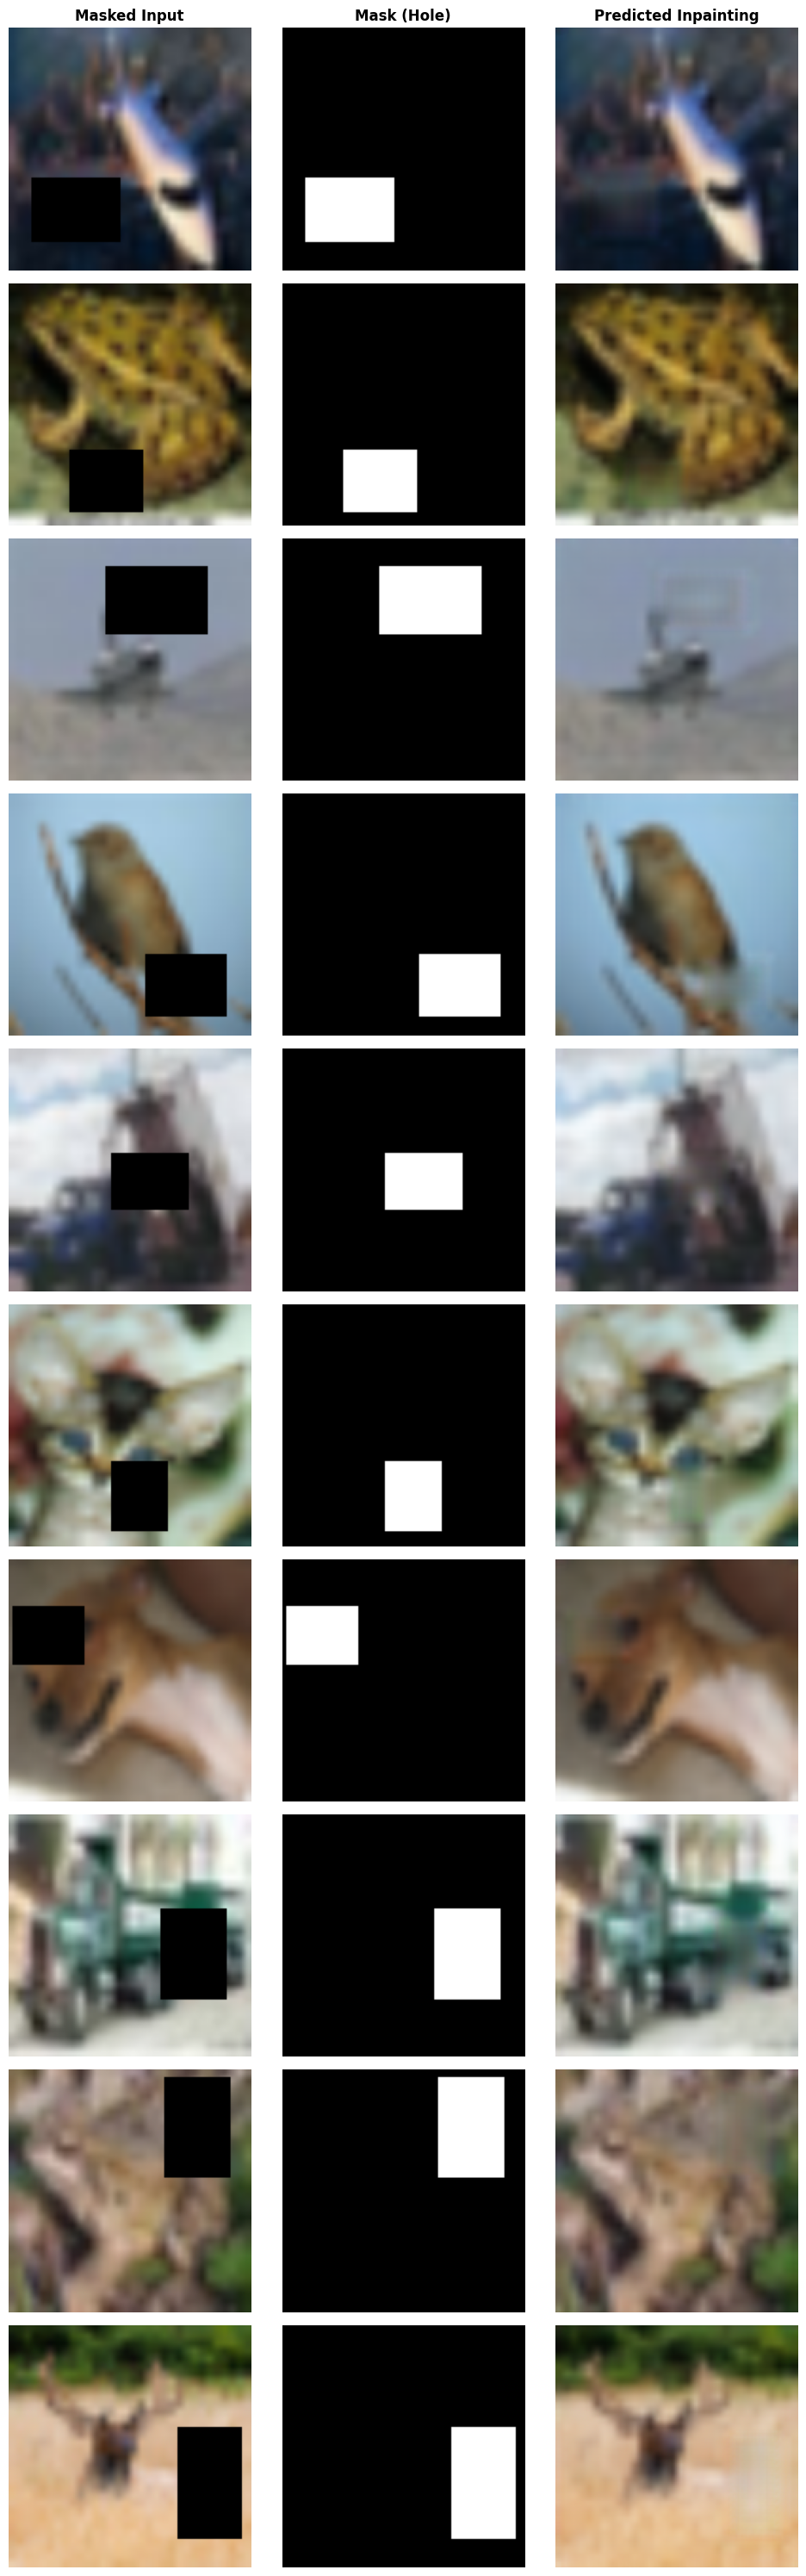

In [12]:
import matplotlib.pyplot as plt
import torch
import random

def visualize_random_predictions(model, dataset, device="cpu", num_samples=10):
    """
    Takes a trained LaMa model and dataset, picks random examples, 
    and plots a grid of: Masked Input | The Mask Itself | Predicted Output
    """
    model.eval()
    model.to(device)
    
    # 1. Pick random indices
    indices = random.sample(range(len(dataset)), num_samples)
    
    # 2. Prepare plot
    fig, axes = plt.subplots(num_samples, 3, figsize=(10, 3 * num_samples))
    # Add column headers
    cols = ["Masked Input", "Mask (Hole)", "Predicted Inpainting"]
    for ax, col in zip(axes[0], cols):
        ax.set_title(col, fontsize=12, fontweight='bold')

    # 3. Process each sample
    with torch.no_grad():
        for i, idx in enumerate(indices):
            sample = dataset[idx]
            
            # Prepare tensors (Add batch dimension: [C,H,W] -> [1,C,H,W])
            ground_truth = sample["ground_truth"].to(device).unsqueeze(0)
            masked_img = sample["masked_image"].to(device).unsqueeze(0)
            mask = sample["mask"].to(device).unsqueeze(0)
            
            # Inference
            prediction = model(masked_img, mask)
            
            # --- Visualization Processing ---
            
            # A. Masked Input: Convert to CPU -> numpy -> [H,W,C]
            # We add a grey tint to the hole for better visibility instead of pure black
            viz_input = masked_img.squeeze().cpu().permute(1, 2, 0).numpy()
            viz_mask = mask.squeeze().cpu().numpy()
            
            # B. Mask: Just the binary mask (Black/White)
            # viz_mask is already prepared above
            
            # C. Prediction: Convert to CPU -> numpy -> [H,W,C]
            viz_pred = prediction.squeeze().cpu().permute(1, 2, 0).numpy()
            
            # --- Plotting ---
            
            # Column 1: Masked Input
            axes[i, 0].imshow(viz_input)
            axes[i, 0].axis('off')
            
            # Column 2: The Mask
            axes[i, 1].imshow(viz_mask, cmap='gray')
            axes[i, 1].axis('off')
            
            # Column 3: Prediction
            axes[i, 2].imshow(viz_pred)
            axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

dataset = InpaintingDataset(img_size=128)
visualize_random_predictions(model, dataset, device=device)